In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation
from scipy.sparse.linalg import spsolve

Mass matrix initialization completed
Stiffness matrix initialization completed


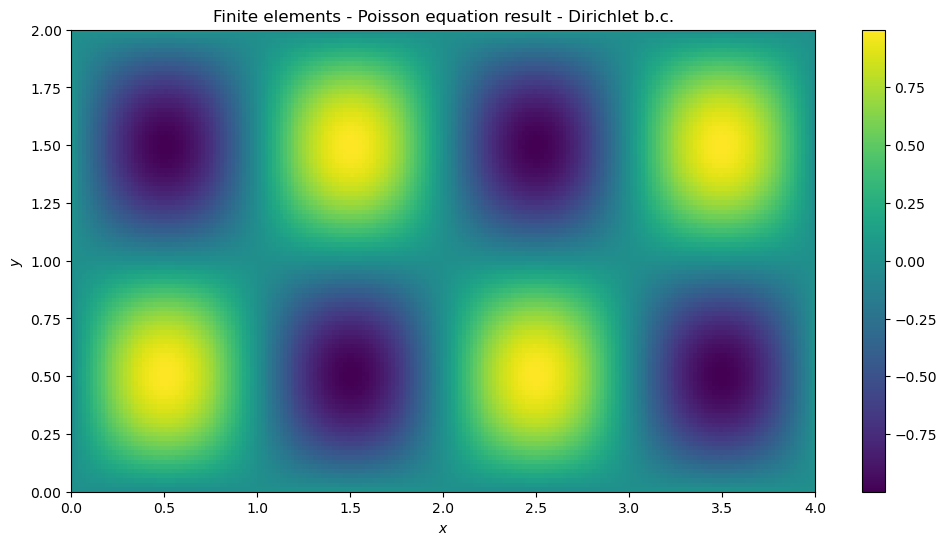

In [2]:
# As a reference solution, first compute the solution with the finite elements methods

x = np.linspace(0, 4, 200)
y = np.linspace(0, 2, 100)

mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

func = lambda x,y: 2.0 * np.pi**2 * np.sin(np.pi * x) * np.sin(np.pi * y)
diri = lambda x,y: 0
res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)

plt.figure(figsize=(12, 6))
plt.imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('Finite elements - Poisson equation result - Dirichlet b.c.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/poisson.png')


In [ ]:
# Example of a basic case for automatic differentiation with PyTorch (just for me to understand how to use PyTorch with a simple example)

x = torch.tensor(3.0, requires_grad=True)
y = x**2
y.backward()
# y.backward() saves the gradient back on x. Note that backward destryos the graph, so if I want to apply the graph another time I have to add retain_graph = True
print(x.grad)

tensor(6.)


In [4]:
f_poisson_torch = lambda x: 2.0 * torch.pi**2 * torch.sin(torch.pi * x[:, 0:1]) * torch.sin(torch.pi * x[:, 1:2])

trial_PINN = PINN_Poisson_2d(32, f_poisson_torch, lambda x: 0)
# attention, the Dirichlet and Poisson functions take lists [x, y] as inputs
trial_PINN.set_collocation_points(400, (0,4), (0,2))
trial_PINN.compute_boundary_values(100, (0,4), (0,2))

trial_PINN.train(100000)

Epoch [1000/100000], Loss: 0.0704
Epoch [2000/100000], Loss: 0.0567
Epoch [3000/100000], Loss: 0.0647
Epoch [4000/100000], Loss: 0.0112
Epoch [5000/100000], Loss: 0.0088
Epoch [6000/100000], Loss: 0.0046
Epoch [7000/100000], Loss: 0.0397
Epoch [8000/100000], Loss: 0.0146
Epoch [9000/100000], Loss: 0.0166
Epoch [10000/100000], Loss: 0.0107
Epoch [11000/100000], Loss: 0.0214
Epoch [12000/100000], Loss: 0.0049
Epoch [13000/100000], Loss: 0.0268
Epoch [14000/100000], Loss: 0.0105
Epoch [15000/100000], Loss: 0.0496
Epoch [16000/100000], Loss: 0.0216
Epoch [17000/100000], Loss: 0.0070
Epoch [18000/100000], Loss: 0.0261
Epoch [19000/100000], Loss: 0.0057
Epoch [20000/100000], Loss: 0.0536
Epoch [21000/100000], Loss: 0.0204
Epoch [22000/100000], Loss: 0.0168
Epoch [23000/100000], Loss: 0.0113
Epoch [24000/100000], Loss: 0.0484
Epoch [25000/100000], Loss: 0.0096
Epoch [26000/100000], Loss: 0.0712
Epoch [27000/100000], Loss: 0.0029
Epoch [28000/100000], Loss: 0.0318
Epoch [29000/100000], Loss: 0

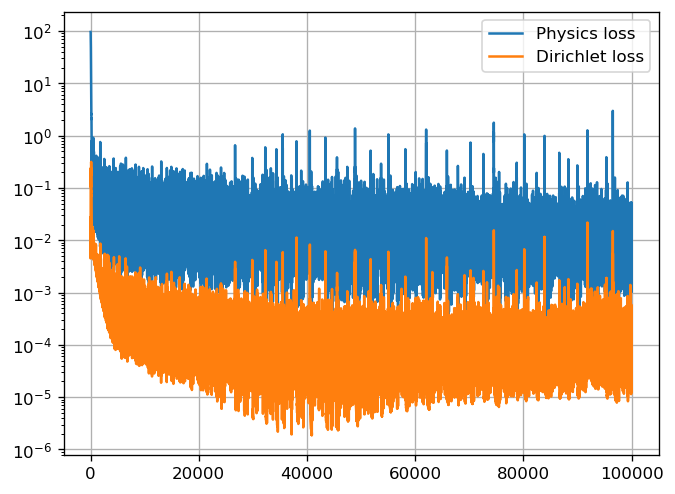

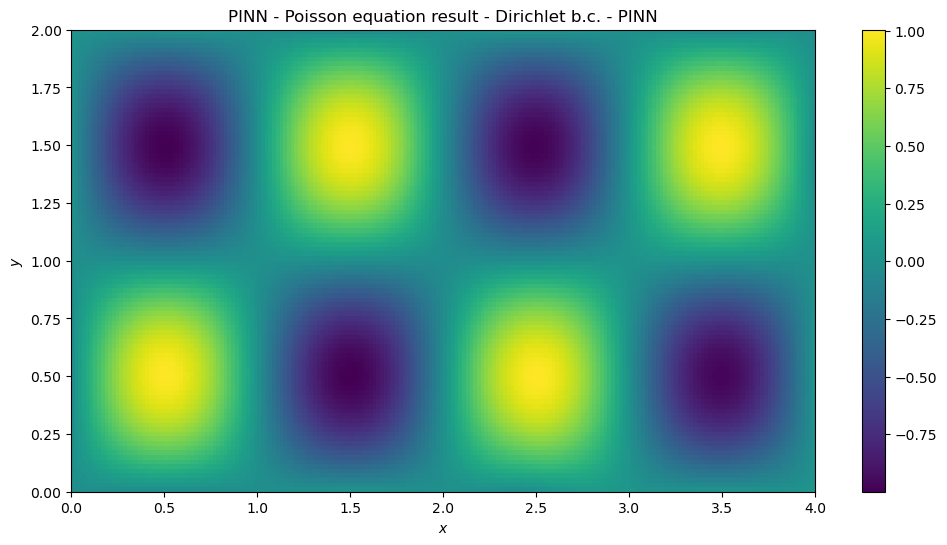

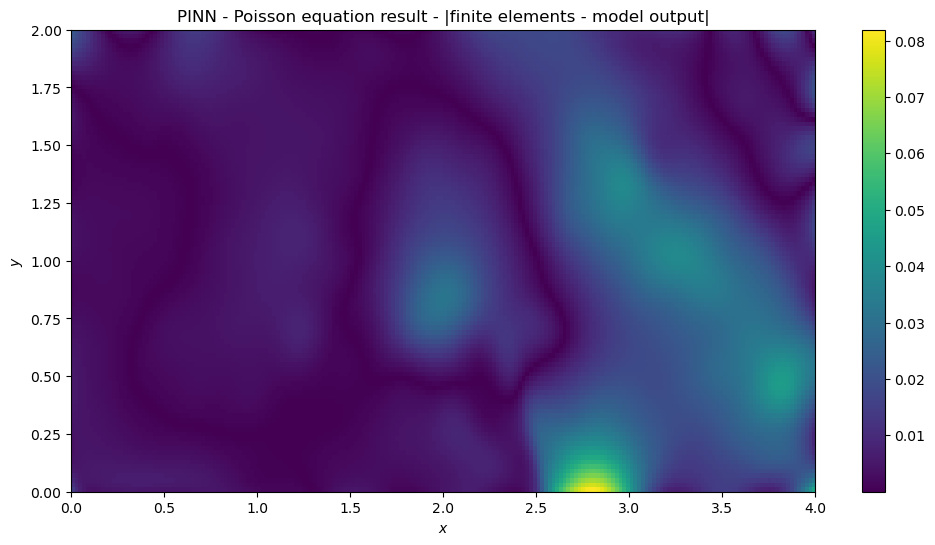

In [5]:

plt.figure(dpi= 120)
plt.semilogy(trial_PINN.epochs, trial_PINN.physics_losses, label = "Physics loss")
plt.semilogy(trial_PINN.epochs, trial_PINN.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()

x = np.linspace(0, 4, 200)
y = np.linspace(0, 2, 100)

# build (N, 2) grid points in the same row-major order as imshow expects: shape (len(y), len(x))
X, Y = np.meshgrid(x, y)  # X, Y both shape (100, 200)
grid_points = np.stack([X.ravel(), Y.ravel()], axis=1)  # shape (20000, 2)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)

with torch.no_grad():
    u_pred = trial_PINN.model(grid_points_torch)  # shape (20000, 1)

res = u_pred.numpy().reshape(len(y), len(x))  # back to (100, 200) to match X, Y grid

plt.figure(figsize=(12, 6))
plt.imshow(res, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title('PINN - Poisson equation result - Dirichlet b.c. - PINN')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/poisson_pinn.png')
plt.show()


plt.figure(figsize=(12, 6))
plt.imshow(np.abs(res - res_finite_elements), cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title('PINN - Poisson equation result - |finite elements - model output|')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/difference_FE_PINN_poisson.png')
plt.show()

pretty large values for both losses, especially the physics loss? 

**TO DO: tests varying dimensions and number of collocation and boundary points. When best convergence and overall results?**

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation

Mass matrix initialization completed
Stiffness matrix initialization completed
(50, 50)


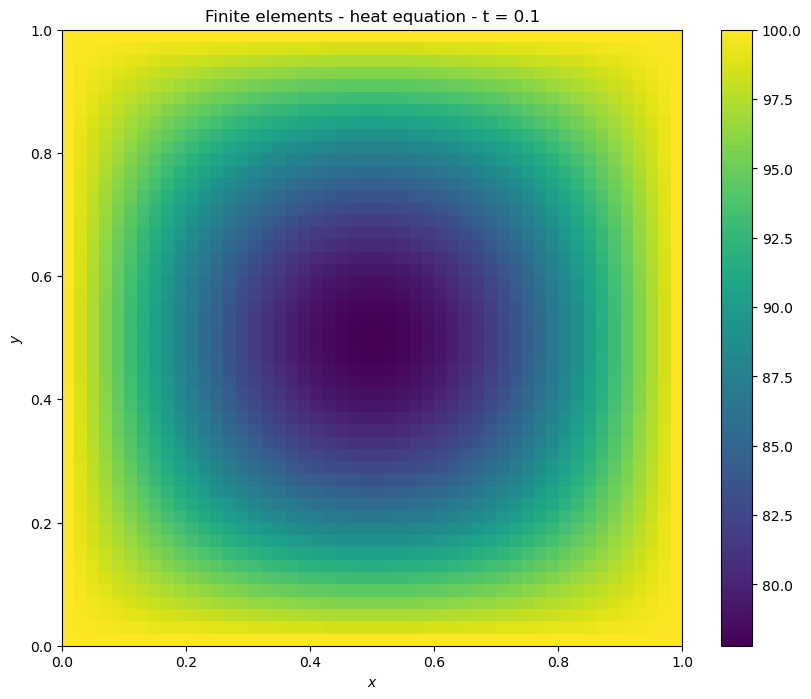

In [28]:
# first, finite elemetn solution for reference
# Implicit midpoint rule (Crank-Nicolson) for time evolution

# grid:
Nx = Ny = 50
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
u0 = np.zeros(Nx*Ny)
# set initial conditions
for i in [0, Nx-1]:
    for j in range(0, Ny):
                u0[Ny*i + j] = 100
for j in [0, Ny-1]:
    for i in range(1, Nx - 1):
                u0[Ny*i + j] = 100
u = u0.copy()

# prepare the simulation 
mymesh = Mesh(x, y, verbose=True)

steps = 200
times, dt = np.linspace(0, 0.1, steps, retstep = True)
alpha = 1

t_check = 0.1
# Build matrices once before the time loop (expensive to rebuild every step)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

M = mymesh.M.tocsr()
S = mymesh.S.tocsr()
# Precompute LHS matrix needed for the implicit midpoint rule — it stays constant over the timestep iteration
LHS = (M + (dt * alpha / 2) * S).tolil()

# Apply boundary conditions to LHS once (zero row, set diagonal to 1)
bc_indices = []
for i in [0, Nx - 1]:
    for j in range(0, Ny):
        bc_indices.append(Ny * i + j)
for j in [0, Ny - 1]:
    for i in range(1, Nx - 1):
        bc_indices.append(Ny * i + j)
bc_indices = list(set(bc_indices))
for idx in bc_indices:
    LHS[idx, :] = 0
    LHS[idx, idx] = 1
LHS = LHS.tocsr()  # convert once for efficient solving

for t in times:
    # fompute RHS: (M - dt*alpha/2 * S) * u
    RHS_vec = (M - (dt * alpha / 2) * S).dot(u)

    # apply boundary conditions to RHS
    for idx in bc_indices:
        RHS_vec[idx] = 100

    # finally, solve the linear system
    u = spsolve(LHS, RHS_vec)

res_FE = u.reshape((Nx, Ny)).transpose()
print(np.shape(res_FE))


# plot the results
plt.figure(figsize=(10, 8))
plt.imshow(res_FE, cmap='viridis', origin='lower', aspect='auto', extent=[0, 1, 0, 1])
plt.colorbar()
plt.title(f'Finite elements - heat equation - t = {t_check}')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/heat_finite_elements.png')
plt.show()

In [12]:
# now try solving the heat equations in 2 spatial dimensions + time 

# initial temperature is 20 inside the geometry (square of side 1), temperature is set to 100 °C on the edge
# work on timespan from 0 to 1
heat_PINN = PINN_heat_2d(48, lambda x: 0, lambda x: 100, (0,1),(0,1), (0,1), alpha = 1)
heat_PINN.set_collocation_points(3000)
heat_PINN.compute_initial_values(1000, 0)
heat_PINN.compute_boundary_values(1000)
heat_PINN.compute_physics_loss()

heat_PINN.train(20000)

Epoch [1000/20000], Loss: 50000.0000
Epoch [2000/20000], Loss: 50022.1250
Epoch [3000/20000], Loss: 2359.8464
Epoch [4000/20000], Loss: 1653.4980
Epoch [5000/20000], Loss: 1060.2019
Epoch [6000/20000], Loss: 2380.5269
Epoch [7000/20000], Loss: 544.1924
Epoch [8000/20000], Loss: 640.4060
Epoch [9000/20000], Loss: 1128.6371
Epoch [10000/20000], Loss: 1093.3118
Epoch [11000/20000], Loss: 1079.0668
Epoch [12000/20000], Loss: 1564.5854
Epoch [13000/20000], Loss: 2214.9470
Epoch [14000/20000], Loss: 1250.2255
Epoch [15000/20000], Loss: 728.1409
Epoch [16000/20000], Loss: 997.4775
Epoch [17000/20000], Loss: 2405.0044
Epoch [18000/20000], Loss: 589.7571
Epoch [19000/20000], Loss: 674.7905
Epoch [20000/20000], Loss: 1381.9663


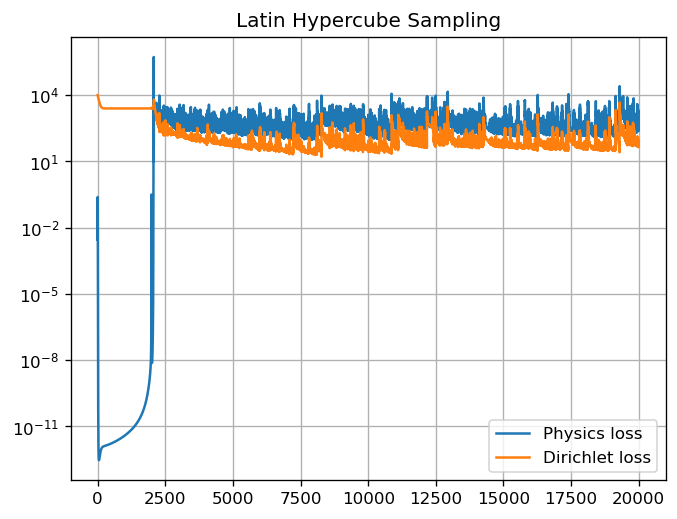

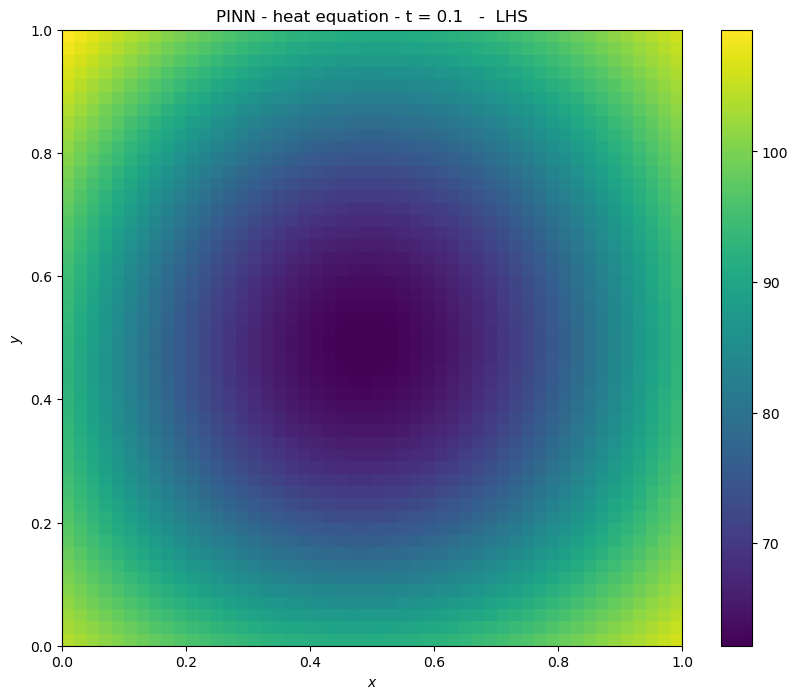

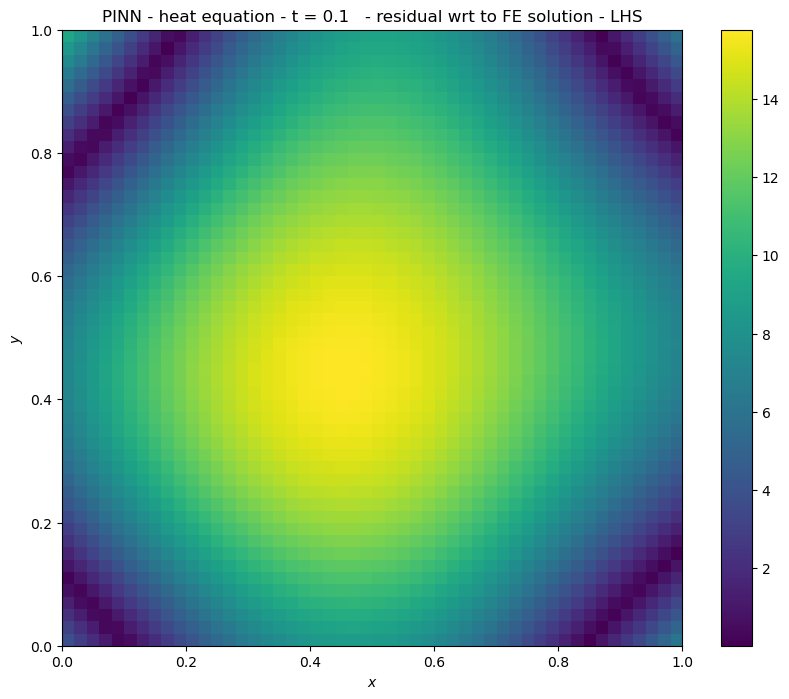

In [29]:

plt.figure(dpi= 120)
plt.title('Latin Hypercube Sampling')
plt.semilogy(heat_PINN.epochs, heat_PINN.physics_losses, label = "Physics loss")
plt.semilogy(heat_PINN.epochs, heat_PINN.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()


t_check = 0.1
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)

# build (N, 2) grid points in the same row-major order as imshow expects: shape (len(y), len(x))
X, Y = np.meshgrid(x, y)  # X, Y both shape (100, 200)
grid_points = np.stack([X.ravel(), Y.ravel(), t_check * np.ones_like(X.ravel())], axis=1)  # shape (..., 2)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)
# compute solution at t = 0.1
with torch.no_grad():
    u_pred = heat_PINN.model(grid_points_torch)  # shape (..., 1)

res = u_pred.numpy().reshape(Nx, Ny)  # back to (Nx, Ny) to match X, Y grid

plt.figure(figsize=(10, 8))
plt.imshow(res, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title(f'PINN - heat equation - t = {t_check}   -  LHS')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()


plt.figure(figsize=(10, 8))
plt.imshow(np.abs(res - res_FE), cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title(f'PINN - heat equation - t = {t_check}   - residual wrt to FE solution - LHS')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()


In [ ]:
# now try training with the RAR-G algorithm (residual-based adaptive finement with greed)

# initial temperature is 20 inside the geometry (square of side 1), temperature is set to 100 °C on the edge
# work on timespan from 0 to 1
heat_PINN = PINN_heat_2d(48, lambda x: 0, lambda x: 100, (0,1),(0,1), (0,1), alpha = 1)
heat_PINN.set_collocation_points(500)
heat_PINN.compute_initial_values(200, 0)
heat_PINN.compute_boundary_values(200)
heat_PINN.compute_physics_loss()

heat_PINN.train_RARG(20000)

Epoch [1000/30000], N_collocation_points: 650, Loss: 50000.0000
Epoch [2000/30000], N_collocation_points: 850, Loss: 50000.0000
Epoch [3000/30000], N_collocation_points: 1050, Loss: 50000.0000
Epoch [4000/30000], N_collocation_points: 1250, Loss: 10051.0527
Epoch [5000/30000], N_collocation_points: 1450, Loss: 5464.6719
Epoch [6000/30000], N_collocation_points: 1650, Loss: 5543.2427
Epoch [7000/30000], N_collocation_points: 1850, Loss: 4597.6138
Epoch [8000/30000], N_collocation_points: 2050, Loss: 5065.6387
Epoch [9000/30000], N_collocation_points: 2250, Loss: 4596.8804
Epoch [10000/30000], N_collocation_points: 2450, Loss: 4104.2817
Epoch [11000/30000], N_collocation_points: 2650, Loss: 3967.0234
Epoch [12000/30000], N_collocation_points: 2850, Loss: 4695.7676
Epoch [13000/30000], N_collocation_points: 3050, Loss: 4430.2163
Epoch [14000/30000], N_collocation_points: 3250, Loss: 3677.1055
Epoch [15000/30000], N_collocation_points: 3450, Loss: 3471.1396
Epoch [16000/30000], N_collocati

AttributeError: 'PINN_heat_2d' object has no attribute 'epochs'

<Figure size 768x576 with 0 Axes>

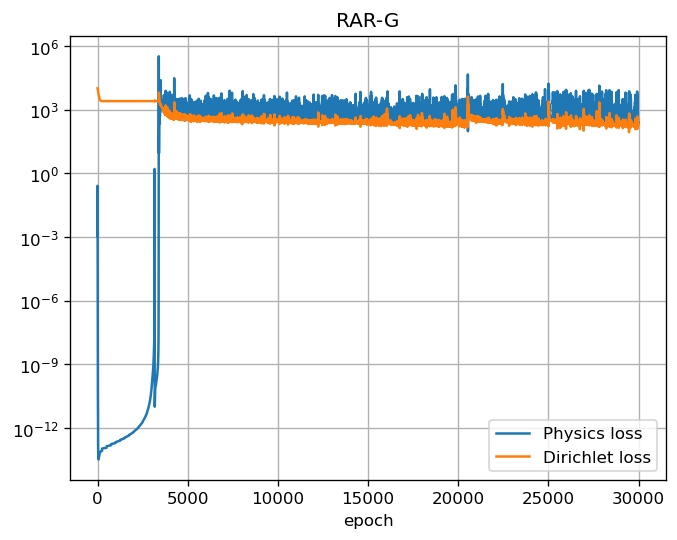

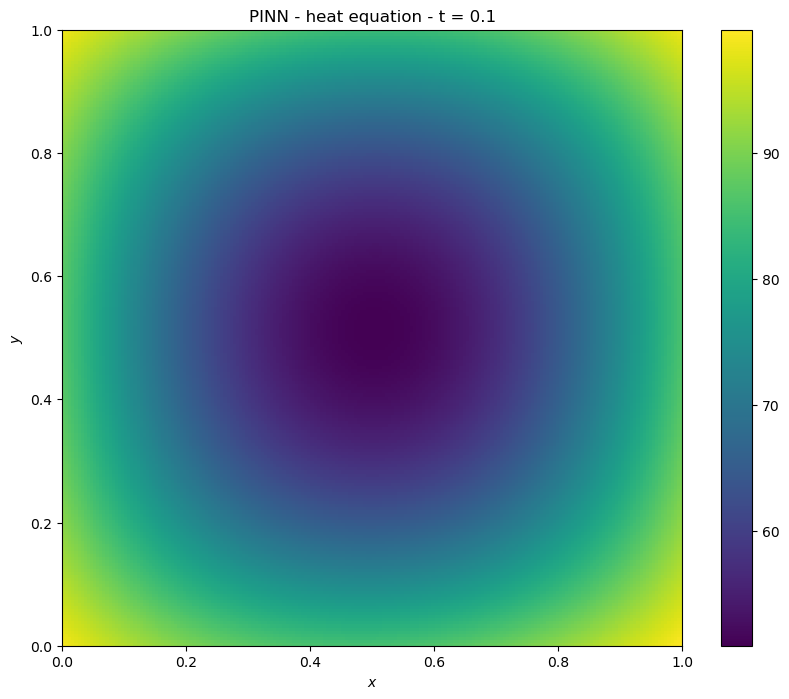

In [ ]:
plt.figure(dpi= 120)
plt.title("RAR-G")
plt.xlabel('epoch')
plt.semilogy(heat_PINN.physics_losses, label = "Physics loss")
plt.semilogy(heat_PINN.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()

t_check = 0.1

# build (N, 2) grid points in the same row-major order as imshow expects: shape (len(y), len(x))
X, Y = np.meshgrid(x, y)  # X, Y both shape (100, 200)
grid_points = np.stack([X.ravel(), Y.ravel(), t_check * np.ones_like(X.ravel())], axis=1)  # shape (20000, 2)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)
# compute solution at t = 1
with torch.no_grad():
    u_pred = heat_PINN.model(grid_points_torch)  # shape (20000, 1)

res = u_pred.numpy().reshape(len(y), len(x))  # back to (100, 200) to match X, Y grid

plt.figure(figsize=(10, 8))
plt.imshow(res, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title(f'PINN - heat equation - t = {t_check}.  -  RAR-G')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/heat_pinn.png')
plt.show()


plt.figure(figsize=(10, 8))
plt.imshow(np.abs(res - res_FE), cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title(f'PINN - heat equation - t = {t_check}   - residual wrt to FE solution - RAR-G')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

**things to try for PINN**


Hard-constrain the boundary/initial conditions: my problem is that it seems to converge first to the trivial solution; this is a known problem


**Normalization of the loss ?? numbers are really high...**



**TO IMPLEMENT: RAD (residual-based adaptive distribution)**